# Aula 19

# Callbacks


### Eduardo Lobo Lustosa Cabral

## 1. Introdução e objetivos

Callbacks são ferramentas que permitem personalizar o processo de treinamento de uma rede neural.

Callbacks são funções chamadas em pontos específicos durante o treinamento, como no início de cada época, no final de cada época, ou após cada lote.

Usando callbacks, pode-se monitorar o treinamento, salvar modelos, ajustar hiperparâmetros etc.

Os objetivos dessa aula são os seguintes:

1. Apresentar os principais callbacks

2. Apresentar como criar um callback customizado

Documentação oficial do Keras sobre callbacks: https://keras.io/api/callbacks/


## Importando as bibliotecas necessárias

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
tf.__version__

'2.17.0'

## 2. Conjunto de dados

Vamos usar o conjunto de dados de dígitos MNIST, que consiste de imagens em tons de cinza de números de 0 a 9 escritos a mão.

In [ ]:
(Xtrain, Ytrain), (Xtest, Ytest) = tf.keras.datasets.mnist.load_data()
print('Xtrain.shape: ', Xtrain.shape)
print('Ytrain.shape: ', Ytrain.shape)
print('Xtest.shape: ', Xtest.shape)
print('Ytest.shape: ', Ytest.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Xtrain.shape:  (60000, 28, 28)
Ytrain.shape:  (60000,)
Xtest.shape:  (10000, 28, 28)
Ytest.shape:  (10000,)


Normalização dos dados de entrada e codificação one-hot das saídas.

In [ ]:
# Normalização das entradas
x_train = Xtrain/255.
x_test = Xtest/255.

# Codificação one-hot das saídas
y_train_hot = tf.keras.utils.to_categorical(Ytrain, 10)
y_test_hot = tf.keras.utils.to_categorical(Ytest, 10)

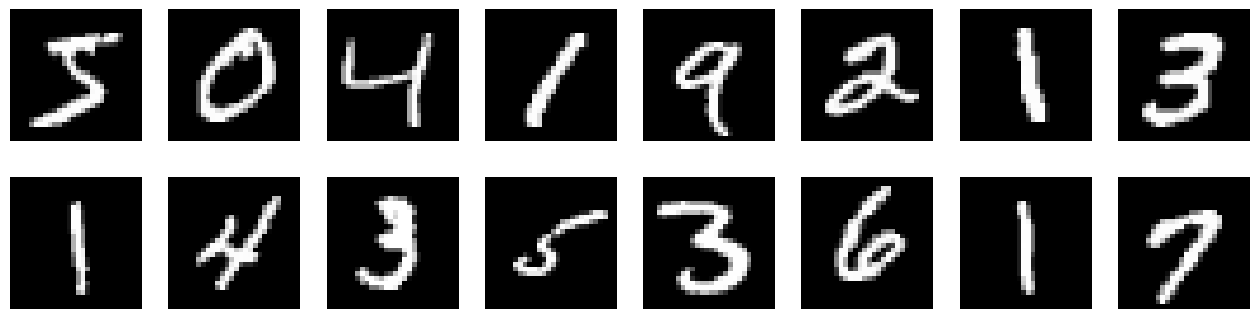

In [ ]:
fig, axs = plt.subplots(2, 8, figsize=(16, 4))
index = 0
for i in range(2):
    for j in range(8):
        axs[i,j].imshow(Xtrain[index], cmap='gray')
        index += 1
        axs[i,j].axis('off')
plt.show()

## 3. EarlyStopping

O callback EarlyStopping realiza a parada automatica de um treinamento.

O EarlyStopping é um callback útil no treinamento de redes neurais pelos seguintes motivos:

- "Prevenir overfitting": como visto uma forma de prevenir overfitting é parar o treinamento de forma prematura.

- Economizar tempo: é possível evitar treinar por mais épocas do que o necessário, otimizando o uso de recursos computacionais.

- Simplifica a seleção do número de épocas, pois elimina a necessidade de definir manualmente o número ideal de épocas.

Esse callback monitora uma métrica específica durante o treinamento e interrompe o processo quando essa métrica parar de melhorar por um número pré-definido de épocas.

**Principais argumentos:**

- `monitor`: define o parâmetro do processo de treinamento que é monitorado para realizar a parada. Esse parâmetro pode ser a função de custo ou alguma métrica, tanto dos dados de treinamento como de validação. Opções comuns incluem 'val_loss', 'val_accuracy', 'loss', 'accuracy'.

- `patience`: parâmetro que define o número máximo de épocas que a grandeza escolhida pode permanecer sem melhoria antes que o treinamento seja interrompido.

- `min_delta`: define o que se considera uma melhoria do valor monitorado, esse argumento representa a menor mudança que é considerada significativa.

- `mode`: pode ser 'auto', 'min', ou 'max' $\to$ indica se a grandeza monitorada deve ser minimizada ou maximizada.

- `restore_best_weights`: se for `True`, os pesos do modelo serão restaurados para a época com a melhor grandeza monitorada.

Se a métrica não melhorar no mínimo pelo valor definido por `min_delta` pelo número de épocas especificado em `patience`, então, o treinamento é interrompido.

Um exemplo desse callback segue na célula abaixo.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, min_delta=0.001)

- Nesse caso está monitorando `val_accuracy` e se ela não diminuir 0,001 por 10 épocas então o treinamento é interrompido

## 4. ModelCheckpoint

Ele callback permite salvar o modelo durante o processo de treinamento.

Ele permite salvar o modelo em cada época, ou apenas quando uma grandeza específica melhora.

Salvar um modelo é muito importante, por diversos motivos:

1. Recuperar o melhor modelo: no final do treinamento, é possível carregar o modelo salvo com o melhor desempenho, evitando a necessidade de refazer todo o treinamento.

2. Realizar experimentos: pode-se salvar modelos em diferentes pontos do treinamento para comparar resultados e ajustar hiperparâmetros.

3. Continuar o treinamento a partir do último modelo salvo, se o mesmo for interrompido por algum motivo.

**Principais argumentos:**

- Nome do arquivo: o caminho do arquivo onde o modelo será salvo.
- `monitor`: o callback monitora uma grandeza escolhida, tal como, função de custo ou métrica dos dados de treinamento ou validação.
- `save_best_only`: se for True, salva apenas o melhor modelo até o momento.
- `mode`: pode ser 'auto', 'min', ou 'max' $\to$ indica se a grandeza deve ser minimizada ou maximizada.
- `save_weights_only`: se for True, salva apenas os pesos do modelo.
- `verbose`: define se mostra informação quando um modelo é salvo.


**Observações:**

- Condição de salvamento: quando a métrica satisfazer a condição desejada, por exemplo, atingir o melhor valor até o momento, então, o modelo é salvo em um arquivo.
- Frequência de salvamento: ao definir `save_best_only=False`, o modelo é salvo a cada época.
- Formato do modelo salvo: o formato keras é o atualmente o formato padrão para salvar modelos Keras.


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint('best_model.keras',
                             monitor='val_accuracy',
                             save_best_only=True,
                             mode='max',
                             verbose=1)

- Nesse caso a `val_accuracy`está sendo monitorada e quando ela melhora o modelo é salvo no arquivo 'best_model.keras'. Além disso, todo vez que o modelo é salvo é avisado durante o treinamento.

## 5. Taxa de aprendizado variável

A variação da taxa de aprendizado durante o treinamento é realizada no TensorFlow/Keras usando o callback **LearningRateScheduler**.

Note que variar a taxa de aprendizado durante o treinamento de uma rede neural pode melhorar a convergência e o desempenho do modelo.

Como vimos, uma taxa de aprendizado muito alta pode levar a oscilações e divergência, enquanto uma taxa muito baixa pode tornar o treinamento muito lento $\to$ uma programação de taxa de aprendizado bem definida pode ajudar a encontrar um bom equilíbrio.

O callback LearningRateScheduler recebe uma função que retorna a nova taxa de aprendizado a cada época.

Existem diversas formas de agendar a taxa de aprendizado. Como vimos, algumas opções comuns incluem:

- Decaimento exponencial: a taxa de aprendizado diminui exponencialmente a cada época.
- Decaimento por passo: a taxa de aprendizado é reduzida por um fator fixo a cada certo número de épocas.
- Plateau: a taxa de aprendizado é reduzida quando a métrica de validação para de melhorar.

Na célula abaixo são mostrados dois exemplos de como variar a taxa de aprendizado:

1. Decaimento por passo;
2. Decaimento exponencial.

In [ ]:
# Importa callback de programaçãp da taxa de aprendizado
from tensorflow.keras.callbacks import LearningRateScheduler

# Função para variar a taxa de aprendizado por passo
def step_scheduler(epoch):
    if epoch < 10:
        return 0.01
    else:
        return 0.001

# Criando o callback
lr_scheduler_step = LearningRateScheduler(step_scheduler)

# Função para variar a taxa de aprendizado exponencialmente
def exponential_decay(lr0, s):
    def decay(epoch):
        return lr0 * 0.1**(epoch / s)
    return decay

# Criando o callback
lr_scheduler_exp = LearningRateScheduler(exponential_decay(0.01, 20))

- Função `step_scheduler`: define como a taxa de aprendizado será atualizada a cada época. No exemplo, a taxa é 0.01 para as primeiras 10 épocas e 0.001 para as demais.

- Função `exponential_decay`: define como é realizado o decaimento exponencial da taxa de aprendizado; `lr0` é a taxa de aprendizado inicial e `s` é uma constante usada para definir a velocidade da diminuição da taxa.

- `LearningRateScheduler`: cria um objeto callback que passa a função scheduler para o otimizador.

## 6. Exemplo

Vamos treinar um modelo simples usando esses 3 callbacks que configurados.

Vamos utilizar um modelo com camadas densas para resolver o problema de classificação multiclasse dos digitos MNIST.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Modelo sequencial
def build_model(input_shape):
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    return model

# Cria modelo
model = build_model(input_shape=(28, 28))

# Compilando o modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Os callbacks desejados são adicionados à lista de callbacks durante o treinamento.

In [ ]:
# Treinando o modelo
history = model.fit(x_train, y_train_hot,
                    epochs=100,
                    validation_data=(x_test, y_test_hot),
                    callbacks=[early_stop, checkpoint, lr_scheduler_exp])


Epoch 1/100
1857/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8803 - loss: 0.4001
Epoch 1: val_accuracy improved from -inf to 0.94490, saving model to best_model.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8807 - loss: 0.3989 - val_accuracy: 0.9449 - val_loss: 0.2040 - learning_rate: 0.0100
Epoch 2/100
1859/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9537 - loss: 0.1690
Epoch 2: val_accuracy improved from 0.94490 to 0.95660, saving model to best_model.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9537 - loss: 0.1690 - val_accuracy: 0.9566 - val_loss: 0.1629 - learning_rate: 0.0089
Epoch 3/100
1861/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9640 - loss: 0.1289
Epoch 3: val_accuracy improved from 0.95660 to 0.96030, saving model to best_model.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9640 - loss: 0.1289 - val_accuracy: 0.9603 - val_loss: 0.1670 - learning_rate: 0.0079
Epoch 4/100
1847/1875 ━━━━━━━━━━━━━━━━━━

Visualizando os Resultados

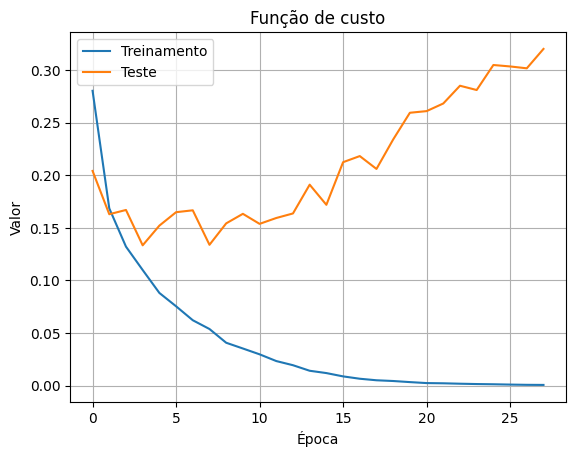

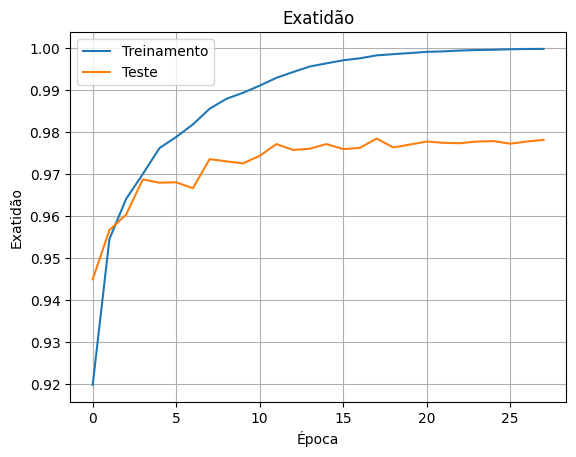

In [ ]:
# Função de custo
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Função de custo')
plt.ylabel('Valor')
plt.xlabel('Época')
plt.legend(['Treinamento', 'Teste'], loc='upper left')
plt.grid()
plt.show()

# Métrica
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Exatidão')
plt.ylabel('Exatidão')
plt.xlabel('Época')
plt.legend(['Treinamento', 'Teste'], loc='upper left')
plt.grid()
plt.show()

## 7. Callbacks personalizados

É possível criar callbacks customizados para tarefas mais específicas. Por exemplo, pode-se criar um callback para salvar imagens geradas por um modelo genartivo ou para enviar notificações por e-mail quando o treinamento terminar.

Para criar um callback customizado tem-se que criar uma classe que herda a classe base Callback do Keras e implementar os métodos que se deseja executar em momentos específicos do treinamento.

Existem alguns métodos disponíveis em um Callback que podem utilizados para executar ações em diferentes momentos do treinamento:

- `on_train_begin`: chamado no início do treinamento.
- `on_train_end`: chamado no final do treinamento.
- `on_epoch_begin`: chamado no início de cada época.
- `on_epoch_end`: chamado no final de cada época.
- `on_batch_begin`: chamado no início de cada lote.
- `on_batch_end`: chamado no final de cada lote.

Nas células a seguir seguem alguns exemplos.

### 7.1 Salvar pesos a cada 10 épocas

O callback da célula abaixo salva os pesos do modelo durante o treinamento a cada `period` épocas.

In [ ]:
# Importa classe Callback
from tensorflow.keras.callbacks import Callback

# Cria classe de callback para salvar pesos
class SaveWeightsEveryN(Callback):
    def __init__(self, filepath, period):
        super(SaveWeightsEveryN, self).__init__()
        self.filepath = filepath
        self.period = period

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.period == 0:
            self.model.save_weights(self.filepath.format(epoch=epoch))

In [ ]:
# Cria modelo
model = build_model(input_shape=(28, 28))

# Compila modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Cria objeto de callback
callback_save_weights = SaveWeightsEveryN(filepath='{epoch:02d}.weights.h5', period=10)

# Trein modelo com o callback
history = model.fit(x_train, y_train_hot, epochs=31, callbacks=[callback_save_weights])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/31
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8939 - loss: 0.3580
Epoch 2/31
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9728 - loss: 0.0852
Epoch 3/31
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9811 - loss: 0.0578
Epoch 4/31
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9855 - loss: 0.0437
Epoch 5/31
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9892 - loss: 0.0329
Epoch 6/31
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9918 - loss: 0.0250
Epoch 7/31
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9925 - loss: 0.0224
Epoch 8/31
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9934 - loss: 0.0196
Epoch 9/31
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9949 - loss: 0.0145
Epoch 10/31
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9957 - loss: 0.0139
Epoch 11/31
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9959 - loss: 0.0129
Epoch 12/31
1875/1875 ━━━━━━━━

- A classe SaveWeightsEveryN herda as propriedades da classe base Callback.

- Inicialização: no construtor são definidos o caminho do arquivo para salvar os pesos e o período em que os pesos são salvos.

### 7.2 Salvar previsões intermediárias

O callback da célula abaixo realiza as seguintes funções:

1. Calcula previsões e métricas no final de algumas épocas (definido por `save_freq`);
2. Calcula uma métrica;
3. Cria um histograma do erro entre as prervisões e as saídas desejadas;
4. Salva gráficos do histograma e das previsões.



In [ ]:
class SaveAndPlotPredictions(Callback):
    def __init__(self, x_val, y_val, save_freq=5, save_path='predictions'):
        super(SaveAndPlotPredictions).__init__()
        self.x_val = x_val
        self.y_val = y_val
        self.save_path = save_path
        self.save_freq = save_freq

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.save_freq == 0:
            # Fazer previsões no conjunto de teste
            predictions = self.model.predict(self.x_val)

            # Salve as previsões em arquivo
            np.save(f"predictions_epoch_{epoch}.npy", predictions)

            # Calcule métricas de interesse (ex: accuracy, MSE)
            val_metrics = logs.get('val_accuracy')
            print(f"Epoch {epoch}: {val_metrics}")

            # Plotar um histograma da diferença entre as previsões e os valores reais
            plt.figure(figsize=(6, 4))
            plt.hist(predictions - self.y_val, bins=30)
            plt.xlabel('Erro')
            plt.ylabel('Frequência')
            plt.title('Histograma dos Erros')
            plt.savefig('error_histogram_epoch'+str(epoch)+'.png')
            plt.grid()
            plt.show()

            # Salve um gráfico comparando as previsões com os valores reais
            plt.figure(figsize=(10, 5))
            plt.plot(np.round(predictions[:100]), 'bo')#, label='Predictions')
            plt.plot(self.y_val[:100], 'ro')#, label='True Values')
            plt.grid()
            #plt.legend()
            plt.savefig(self.save_path+'_epoch_'+str(epoch)+'.png')
            plt.close()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Epoch 0: 0.9692000150680542


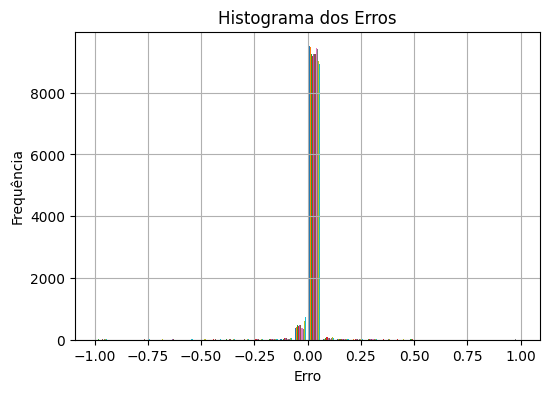

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Epoch 5: 0.9815000295639038


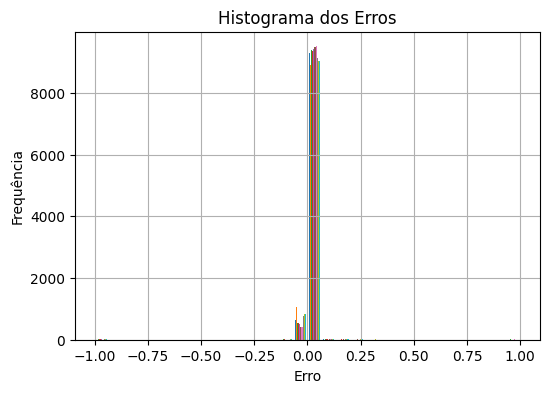

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Epoch 10: 0.9824000000953674


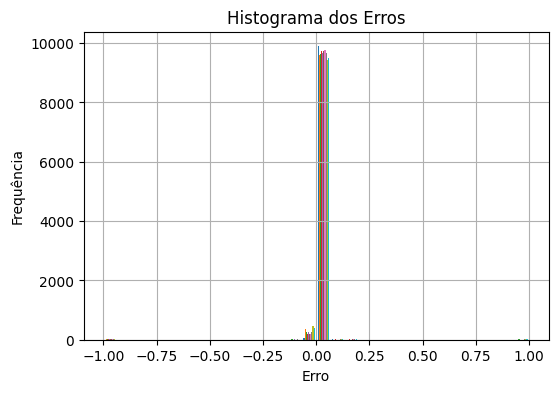

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Epoch 15: 0.9812999963760376


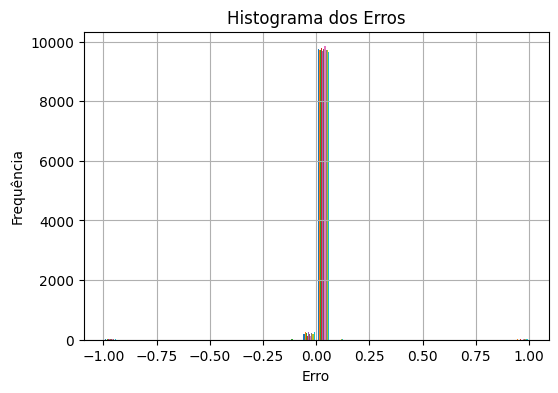

In [ ]:
# Cria modelo
model = build_model(input_shape=(28, 28))

# Compila modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Cria callback
callback_saveplot = SaveAndPlotPredictions(x_test, y_test_hot, save_freq=5)

# Treina modelo
model.fit(x_train, y_train_hot,
          epochs=20,
          validation_data=(x_test, y_test_hot),
          callbacks=[callback_saveplot],verbose=0)

- Inicialização: o construtor recebe o modelo, os dados de validação, o caminho para salvar os gráficos e a frequência de salvamento.

- Método `on_epoch_end`: a cada `save_freq` épocas realiza:
  - Faz previsões no conjunto de validação;
  - Calcula métrica de interesse;
  - Visualiza as previsões;
  - Salva as previsões em um arquivo NumPy;
  - Salva um gráfico comparando as previsões com os valores reais.

### 7.3 Gráfico do processo de treinamento

In [ ]:
# Importa função para apagar saída
from IPython.display import clear_output

# Cria calsse para fazer gráfico durante treinamento
class PlotLearningCurves(Callback):
    def __init__(self):
        self.x = []
        self.losses = []
        self.val_losses = []

    def on_epoch_end(self, epoch, logs={}):
        # Atualiza listas
        self.x.append(int(epoch))
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))

        # Apaga gráfico anterior
        clear_output()

        # Faz o gráfico
        plt.figure()
        plt.plot(self.x, self.losses, 'b', label='Training')
        plt.plot(self.x, self.val_losses, 'r', label='Validation')
        plt.xlabel('Epocas')
        plt.ylabel('Função de custo')
        plt.legend()
        plt.grid()
        plt.show()


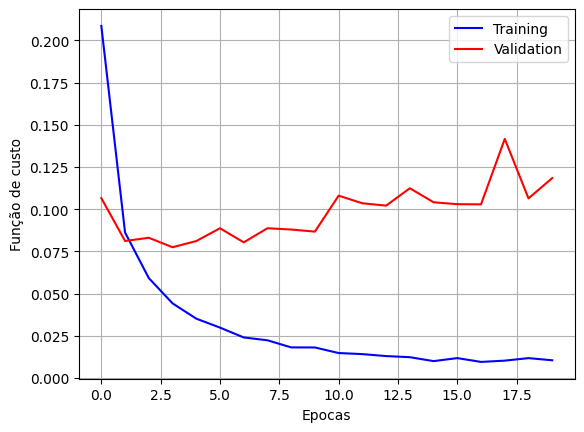

In [ ]:
# Cria modelo
model = build_model(input_shape=(28, 28))

# Compila modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Cria callback
plot_callbacks = PlotLearningCurves()

# Treina modelo
model.fit(x_train, y_train_hot,
          epochs=20,
          validation_data=(x_test, y_test_hot),
          callbacks=[plot_callbacks], verbose=0)

- Inicialização: inicializa as listas para armazenar as épocas e as perdas.

- Método `on_epoch_end`: Atualiza os dados do gráfico com a perda de treinamento e validação da época atual e redesenha o gráfico.